<a href="https://colab.research.google.com/github/edwardcalvinvazc-maker/MLSamples/blob/main/Outliers_Dection_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df = pd.read_csv('/content/credit-card-transaction-fraud-data.csv')
df.head()
df.shape

(7124, 29)

In [ ]:
max_credit = df['credit_score'].quantile(0.95)
max_credit

np.float64(811.0)

In [ ]:
df['credit_score']>max_credit

,credit_score
0,False
1,False
2,False
3,False
4,False
...,...
54995,False
54996,False
54997,False
54998,False


In [ ]:
min_credit = df['credit_score'].quantile(0.05)
min_credit

np.float64(548.0)

In [ ]:
df['credit_score']<min_credit

,credit_score
0,True
1,False
2,False
3,False
4,False
...,...
54995,False
54996,False
54997,False
54998,False


In [ ]:
out_removed = df[(df['credit_score'] < max_credit) & (df['credit_score'] > min_credit)]
out_removed.shape

(49385, 29)

In [ ]:
abnb = pd.read_csv('/content/abnb.csv')
abnb.head()
abnb.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

#Find The Ourtliers

In [ ]:
#Method By using Stats {%}
max_tail = abnb['price'].quantile(0.95)
print('Maximum High Quantile ==',max_tail)

min_tail = abnb['price'].quantile(0.05)
print('Minimum Low Quantile ==',min_tail)
abnb.shape

Maximum High Quantile == 355.0
Minimum Low Quantile == 40.0


(48895, 16)

In [ ]:
out_abnb = abnb[(abnb['price'] < max_tail) & (abnb['price'] > min_tail)]
out_abnb.sample(10)
out_abnb.shape

(43631, 16)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (12,6)


In [ ]:
hdf = pd.read_csv('/content/heights.csv')
hdf.head()

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


In [ ]:
hdf.sample(5)

,gender,height
3494,Male,65.528857
3811,Male,65.976075
7237,Female,63.192350
9572,Female,63.351010
7499,Female,57.148198


In [89]:
hdf.describe()

,height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


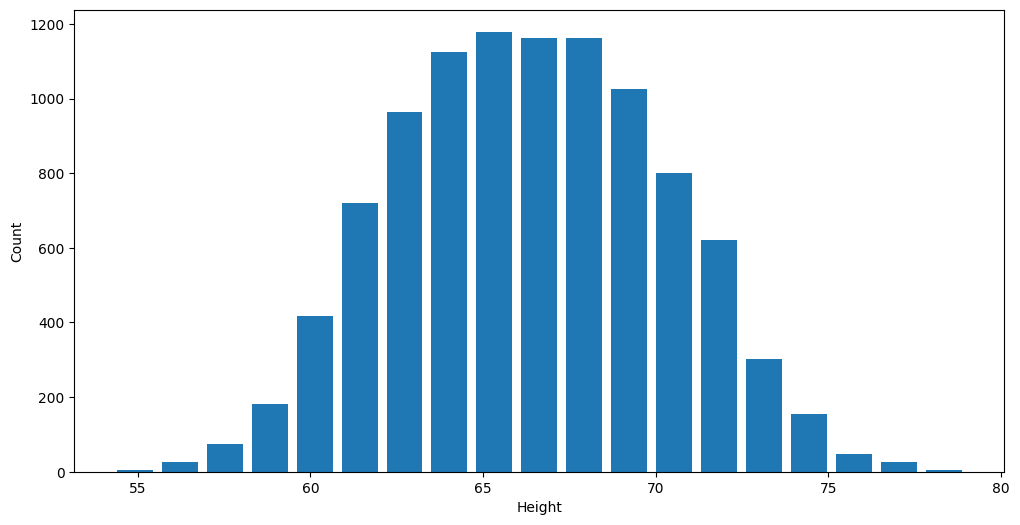

In [88]:
plt.hist(hdf['height'],bins=19,rwidth=0.8)
plt.xlabel('Height')
plt.ylabel('Count')
plt.show()

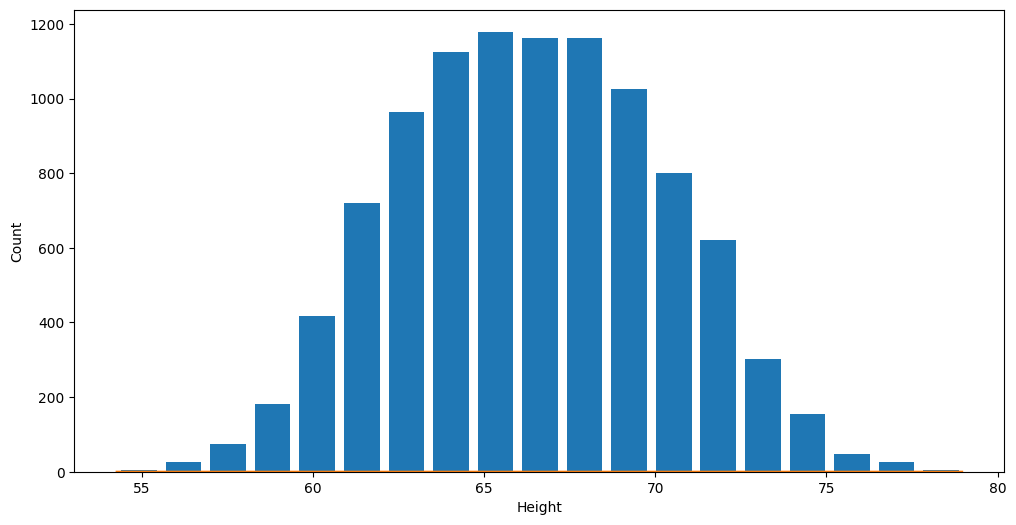

In [111]:
from scipy.stats import norm
import numpy as np

plt.hist(hdf['height'],bins=19,rwidth=0.8)
plt.xlabel('Height')
plt.ylabel('Count')

rng = np.arange(hdf.height.min(),hdf.height.max(),0.1)
plt.plot (rng,norm.pdf(rng,hdf.height.mean(),hdf.height.std()))

In [104]:
max_height = hdf['height'].quantile(0.95)
min_height = hdf['height'].quantile(0.05)
print ('Max Tail',max_height)
print ('Min Tail',min_height)


Max Tail 72.61710606999999
Min Tail 60.246220829500004


In [114]:
upper_limit = hdf.height.mean() + 3*hdf.height.std()
upper_limit

np.float64(77.91014411725271)

In [115]:
lower_limit = hdf.height.mean() - 3*hdf.height.std()
lower_limit

np.float64(54.824975392479274)

In [117]:
hdf[(hdf.height>upper_limit) | (hdf.height<lower_limit)]

,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [123]:
hdf.shape

(10000, 2)

In [124]:
wto_df = hdf[(hdf.height<upper_limit) & (hdf.height>lower_limit)]
wto_df.shape

(9993, 2)

In [127]:
wto_df.sample(10)

,gender,height
6856,Female,68.440567
1130,Male,66.892315
8354,Female,64.644288
3606,Male,65.220379
1713,Male,69.265140
2862,Male,70.963369
6273,Female,63.034260
815,Male,73.962941
9635,Female,63.385061
3869,Male,66.324954


In [131]:
print('NO OF OUTLIER ====',hdf.shape[0] - wto_df.shape[0])

NO OF OUTLIER ==== 7


In [136]:
hdf['zscore'] = (hdf.height - hdf.height.mean()) / hdf.height.std()
hdf.head(5)


,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [147]:
hdf[hdf['zscore']>3]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [146]:
hdf[hdf['zscore']< -3]

,gender,height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [148]:
hdf[(hdf.zscore > 3) | (hdf.zscore < -3)]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [151]:
df = pd.read_csv('/content/bhp.csv')
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


##Outliers Detection Using Quantile

In [187]:
##Using Quantile
min_quant,max_quant = df['price_per_sqft'].quantile([0.001,0.999])
print('Lower bound == ',min_quant)
print('Upper bound ==',max_quant)

percentile_df = df[(df['price_per_sqft']<max_quant) & (df['price_per_sqft']>min_quant)]

print('Rows and Columns Before Removing Outliers === ',df.shape)
print('Rows and Columns After Removing Outliers === ',percentile_df.shape)

outliers_percentile = df[(df['price_per_sqft']>max_quant) | (df['price_per_sqft']<min_quant)]
print('-'*40,'Outliers','-'*40)
outliers_percentile

Lower bound ==  1904.788
Upper bound == 35034.818000000065
Rows and Columns Before Removing Outliers ===  (13172, 7)
Rows and Columns After Removing Outliers ===  (13144, 7)
---------------------------------------- Outliers ----------------------------------------


,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274
130,Electronic City,2 BHK,880.0,1.0,16.5,2,1875
509,Banashankari Stage III,4 Bedroom,8500.0,4.0,145.0,4,1705
982,Chikkabanavar,1 Bedroom,1200.0,1.0,20.0,1,1666
1548,Uttarahalli,5 Bedroom,400.0,5.0,200.0,5,50000
2258,other,4 Bedroom,3200.0,4.0,1200.0,4,37500
2375,Yelahanka New Town,1 BHK,960.0,2.0,18.0,1,1875
4063,other,5 BHK,5800.0,5.0,80.0,5,1379
4502,Channasandra,2 Bedroom,3040.0,2.0,48.0,2,1578
4993,other,6 Bedroom,825.0,6.0,400.0,6,48484


##Outliers Detection Using SD

Upper Bound ==== 22527.46400973184
Lower Bound ==== -9264.707466822527
Rows and Columns Before Removing Outliers ===  (13144, 8)
Rows and Columns of the Outliers ===  (132, 8)
Rows and Columns After Removing Outliers ===  (13012, 8)
======================================== Outliers ========================================


(array([ 155.,  720., 1490., 2067., 1971., 1584., 1160.,  835.,  603.,
         390.,  244.,  246.,  205.,  162.,  158.,  128.,  133.,  108.,
          84.,  104.,   85.,   90.,   43.,   55.,   40.,   31.,   59.,
          28.,   18.,   16.]),
 array([ 1928.        ,  2613.73333333,  3299.46666667,  3985.2       ,
         4670.93333333,  5356.66666667,  6042.4       ,  6728.13333333,
         7413.86666667,  8099.6       ,  8785.33333333,  9471.06666667,
        10156.8       , 10842.53333333, 11528.26666667, 12214.        ,
        12899.73333333, 13585.46666667, 14271.2       , 14956.93333333,
        15642.66666667, 16328.4       , 17014.13333333, 17699.86666667,
        18385.6       , 19071.33333333, 19757.06666667, 20442.8       ,
        21128.53333333, 21814.26666667, 22500.        ]),
 <BarContainer object of 30 artists>)

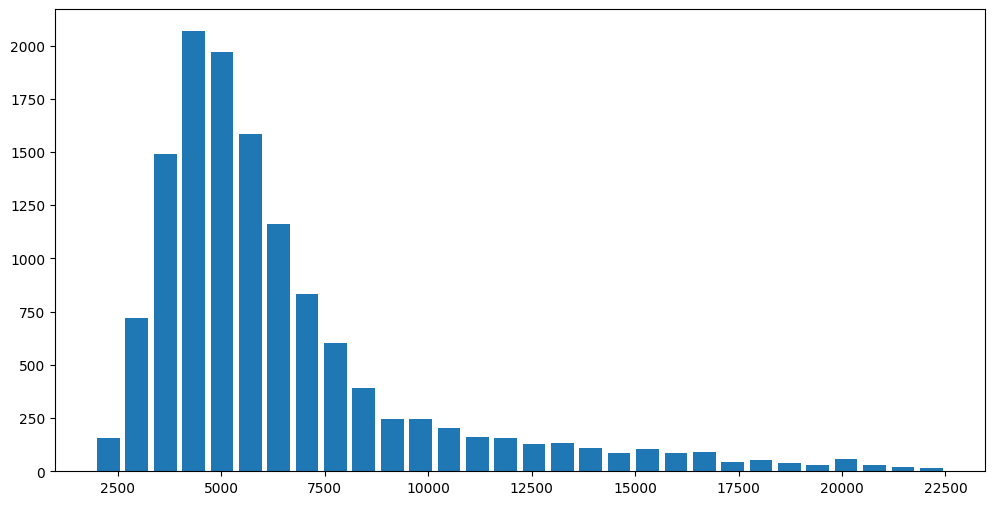

In [243]:
df = percentile_df
df.describe()
upper_4sd = df['price_per_sqft'].mean() + 4*df.price_per_sqft.std()
lower_4sd = df['price_per_sqft'].mean() - 4*df.price_per_sqft.std()

print ('Upper Bound ====',upper_4sd)
print ('Lower Bound ====',lower_4sd)

outliers_sd = df[(df.price_per_sqft>upper_4sd) & (df.price_per_sqft>lower_4sd)]

print('Rows and Columns Before Removing Outliers === ',df.shape)

df = df[(df.price_per_sqft<upper_4sd) | (df.price_per_sqft<lower_4sd)]

print('Rows and Columns of the Outliers === ',outliers_sd.shape)

print('Rows and Columns After Removing Outliers === ',df.shape)
print('='*40,'Outliers','='*40)
outliers_sd.sample(10)

plt.hist(df.price_per_sqft,bins=30,rwidth=0.8)


##Outliers Detection Using Z-score

In [249]:
df = percentile_df
print('Rows and Columns Before Removing Outliers === ',df.shape)
df.head()
df['zscore'] = (df.price_per_sqft - df.price_per_sqft.mean()) / df.price_per_sqft.std()

outliers_zscore = df[(df.zscore > 4) | (df.zscore < -4)]

outliers_zscore.shape

df = df[(df.zscore < 4) & (df.zscore > -4)]
print('Rows and Columns After Removing Outliers === ',df.shape)
print('='*40,'Outliers','='*40)
outliers_zscore


Rows and Columns Before Removing Outliers ===  (13144, 8)
Rows and Columns After Removing Outliers ===  (13012, 8)
======================================== Outliers ========================================


,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333,6.719043
87,Rajaji Nagar,6 Bedroom,710.0,6.0,160.0,6,22535,4.001896
190,Bellandur,4 Bedroom,1200.0,5.0,325.0,4,27083,5.146329
475,other,4 BHK,1150.0,4.0,260.0,4,22608,4.020266
733,Cunningham Road,4 BHK,5270.0,4.0,1250.0,4,23719,4.299831
...,...,...,...,...,...,...,...,...
13078,other,4 Bedroom,9200.0,4.0,2600.0,4,28260,5.442503
13081,other,6 Bedroom,8000.0,6.0,2800.0,6,35000,7.138518
13094,other,4 Bedroom,1200.0,5.0,325.0,4,27083,5.146329
13127,other,4 Bedroom,1200.0,5.0,325.0,4,27083,5.146329


##Outliers Detection Using Inter Quartile Range

In [5]:
df = pd.read_csv('/content/heights.csv')
print(df.shape)


Q1 = df['height'].quantile(0.25)
Q3 = df['height'].quantile(0.75)

IQR = Q3 - Q1

lower_bound_height = Q1  - 1.5 * IQR
uppper_bound_height = Q3  + 1.5 * IQR
print ('Rows and Columns Before Removing Outliers ===',df.shape)


outliers_iqr = df[(df.height > uppper_bound_height) | (df.height < lower_bound_height)]

df = df[(df.height < uppper_bound_height) & (df.height > lower_bound_height)]

print ('Rows and Columns After Removing Outliers ===',df.shape)

outliers_iqr.shape
print('='*40,'Outliers','='*40)
outliers_iqr

(10000, 2)
Rows and Columns Before Removing Outliers === (10000, 2)
Rows and Columns After Removing Outliers === (9992, 2)
======================================== Outliers ========================================


,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
7294,Female,54.873728
9285,Female,54.263133
